In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
print(nav.head())
nav = nav.dropna(subset=["daily_return"])
nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("Daily returns calculated successfully!")

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
Daily returns calculated successfully!


In [21]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])
funds = [
    119551,   # SBI Bluechip
    120503,   # ICICI Bluechip
    118632,   # Nippon Large Cap
    119092,   # Axis Bluechip
    120841    # Kotak Bluechip
]

nav = nav[nav["amfi_code"].isin(funds)]
def calculate_cagr(df, years):

    latest_date = df["date"].max()

    start_date = latest_date - pd.DateOffset(years=years)

    period_df = df[df["date"] >= start_date]

    if len(period_df) < 2:
        return np.nan

    start_nav = period_df.iloc[0]["nav"]
    end_nav = period_df.iloc[-1]["nav"]

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return round(cagr, 2)
results = []

for code in funds:

    fund_df = nav[nav["amfi_code"] == code]

    results.append({
        "amfi_code": code,
        "cagr_1yr": calculate_cagr(fund_df, 1),
        "cagr_3yr": calculate_cagr(fund_df, 3),
        "cagr_5yr": calculate_cagr(fund_df, 5)
    })

cagr_report = pd.DataFrame(results)
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

cagr_report = cagr_report.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print(cagr_report)

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr  \
0     119551     60.44     30.46     22.38   
1     120503      8.49     13.98     16.36   
2     118632     33.98     22.65     20.88   
3     119092      1.61      0.53      5.58   
4     120841     16.84     17.27     11.82   

                                      scheme_name  
0       SBI Bluechip Fund - Regular Plan - Growth  
1      ICICI Pru Bluechip Fund - Regular - Growth  
2  Nippon India Large Cap Fund - Regular - Growth  
3           Axis Bluechip Fund - Regular - Growth  
4          Kotak Bluechip Fund - Regular - Growth  


In [22]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/returns_computed.csv"
)
mean_daily_return = (
    nav.groupby("amfi_code")["daily_return"]
       .mean()
)
annual_return = (
    (1 + mean_daily_return) ** 252 - 1
) * 100
daily_std = (
    nav.groupby("amfi_code")["daily_return"]
       .std()
)
volatility = (
    daily_std * np.sqrt(252)
) * 100
risk_free_rate = 6.5
sharpe_ratio = (
    annual_return - risk_free_rate
) / volatility
sharpe_df = pd.DataFrame({

    "amfi_code": annual_return.index,

    "annual_return_pct":
        annual_return.values,

    "volatility_pct":
        volatility.values,

    "sharpe_ratio":
        sharpe_ratio.values

})
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

sharpe_df = sharpe_df.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)
sharpe_df = sharpe_df.sort_values(

    "sharpe_ratio",

    ascending=False

)
sharpe_df.to_csv(

    "../data/processed/sharpe_values.csv",

    index=False

)

print(sharpe_df.head(10))

    amfi_code  annual_return_pct  volatility_pct  sharpe_ratio  \
34     148567          31.051613       14.193707      1.729753   
30     120843          31.318423       15.886987      1.562186   
36     148569          32.724124       17.674007      1.483768   
25     120505          33.974986       19.290949      1.424242   
19     119551          25.976767       13.741434      1.417375   
38     149323          30.443234       17.746159      1.349207   
2      100033          31.253944       18.936711      1.307193   
9      118632          24.351579       14.148352      1.261743   
3      101206          23.931060       14.568213      1.196513   
24     120504          23.659075       14.363781      1.194607   

                                          scheme_name  
34      Mirae Asset Large Cap Fund - Regular - Growth  
30             Kotak Flexicap Fund - Regular - Growth  
36      Mirae Asset Tax Saver Fund - Regular - Growth  
25           ICICI Pru Midcap Fund - Regular - Gr

In [23]:
import pandas as pd
import numpy as np

# Load returns file
returns_df = pd.read_csv("../data/processed/returns_computed.csv")

# Annualized Return
mean_daily_return = returns_df.groupby("amfi_code")["daily_return"].mean()
annual_return = ((1 + mean_daily_return) ** 252 - 1) * 100

# Downside Standard Deviation
negative_returns = returns_df.copy()
negative_returns.loc[negative_returns["daily_return"] > 0, "daily_return"] = 0

downside_std = (
    negative_returns.groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(252)
    * 100
)

# Risk Free Rate
risk_free_rate = 6.5

# Sortino Ratio
sortino_ratio = (annual_return - risk_free_rate) / downside_std

# Create Output DataFrame
sortino_df = pd.DataFrame({
    "amfi_code": annual_return.index,
    "annual_return_pct": annual_return.values,
    "downside_std_pct": downside_std.values,
    "sortino_ratio": sortino_ratio.values
})

# Add Fund Names
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Rank Funds
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

# Save Output
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("Sortino Ratio Calculation Completed")
print(sortino_df.head(10))

Sortino Ratio Calculation Completed
    amfi_code  annual_return_pct  downside_std_pct  sortino_ratio  \
27     120507           6.976545          0.148769       3.203243   
34     148567          31.051613          7.876553       3.117051   
30     120843          31.318423          8.425803       2.945526   
36     148569          32.724124          9.580838       2.737143   
19     119551          25.976767          7.401208       2.631566   
25     120505          33.974986         10.547369       2.604914   
38     149323          30.443234          9.986055       2.397667   
2      100033          31.253944         10.527569       2.351345   
9      118632          24.351579          7.800104       2.288634   
3      101206          23.931060          7.919589       2.201006   

                                          scheme_name  
27           ICICI Pru Liquid Fund - Regular - Growth  
34      Mirae Asset Large Cap Fund - Regular - Growth  
30             Kotak Flexicap Fund -

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# -----------------------------
# Load Data
# -----------------------------
fund_returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

# -----------------------------
# Convert Dates
# -----------------------------
fund_returns["date"] = pd.to_datetime(
    fund_returns["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# -----------------------------
# Use NIFTY100 Benchmark
# -----------------------------
benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# -----------------------------
# Benchmark Daily Returns
# -----------------------------
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark = benchmark.dropna()

# -----------------------------
# Alpha & Beta Calculation
# -----------------------------
results = []

for fund_code in fund_returns["amfi_code"].unique():

    fund_df = fund_returns[
        fund_returns["amfi_code"] == fund_code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252 * 100

    results.append({
        "amfi_code": fund_code,
        "alpha_pct": round(alpha, 4),
        "beta": round(beta, 4),
        "r_squared": round(regression.rvalue**2, 4)
    })

# -----------------------------
# Create DataFrame
# -----------------------------
alpha_beta_df = pd.DataFrame(results)

# -----------------------------
# Add Fund Names
# -----------------------------
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# -----------------------------
# Save Output
# -----------------------------
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("\nAlpha-Beta Calculation Complete\n")

print(
    alpha_beta_df.sort_values(
        "alpha_pct",
        ascending=False
    ).head(10)
)


Alpha-Beta Calculation Complete

    amfi_code  alpha_pct    beta  r_squared  \
21     119598    30.3370 -0.0232     0.0001   
39     149324    30.0579  0.0115     0.0000   
25     120505    29.2636  0.0005     0.0000   
36     148569    28.2704  0.0181     0.0002   
30     120843    27.3305 -0.0228     0.0003   
2      100033    27.1954  0.0051     0.0000   
34     148567    26.9838  0.0237     0.0005   
38     149323    26.5986 -0.0025     0.0000   
16     119094    26.0767 -0.0663     0.0019   
19     119551    23.2010 -0.0318     0.0009   

                                          scheme_name  
21         SBI Small Cap Fund - Regular Plan - Growth  
39              DSP Small Cap Fund - Regular - Growth  
25           ICICI Pru Midcap Fund - Regular - Growth  
36      Mirae Asset Tax Saver Fund - Regular - Growth  
30             Kotak Flexicap Fund - Regular - Growth  
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  
34      Mirae Asset Large Cap Fund - Regular - Growth  


In [25]:
import pandas as pd
import numpy as np

# -----------------------------
# Load NAV Data
# -----------------------------
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

results = []

# -----------------------------
# Maximum Drawdown Calculation
# -----------------------------
for fund_code in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund_code
    ].copy()

    # Running peak NAV
    fund_df["running_max"] = (
        fund_df["nav"].cummax()
    )

    # Drawdown
    fund_df["drawdown"] = (
        fund_df["nav"] /
        fund_df["running_max"]
        - 1
    )

    # Worst drawdown row
    worst_row = fund_df.loc[
        fund_df["drawdown"].idxmin()
    ]

    results.append({
        "amfi_code": fund_code,
        "max_drawdown_pct":
            round(worst_row["drawdown"] * 100, 2),
        "worst_date":
            worst_row["date"]
    })

# -----------------------------
# Create Output
# -----------------------------
max_dd_df = pd.DataFrame(results)

# -----------------------------
# Add Fund Names
# -----------------------------
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

max_dd_df = max_dd_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# -----------------------------
# Rank Worst Drawdowns
# -----------------------------
max_dd_df = max_dd_df.sort_values(
    "max_drawdown_pct"
)

# -----------------------------
# Save Output
# -----------------------------
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("\nMaximum Drawdown Analysis Complete\n")
print(max_dd_df.head(10))


Maximum Drawdown Analysis Complete

    amfi_code  max_drawdown_pct worst_date  \
22     119599            -52.57 2025-10-28   
17     119095            -51.68 2026-05-11   
4      101207            -35.45 2026-05-11   
39     149324            -31.17 2025-01-03   
21     119598            -28.71 2025-05-14   
7      102886            -28.00 2026-04-27   
0      100016            -24.73 2022-09-15   
29     120842            -24.00 2024-10-17   
11     118634            -23.34 2026-02-20   
15     119093            -21.75 2023-05-22   

                                       scheme_name  
22       SBI Small Cap Fund - Direct Plan - Growth  
17          Axis Small Cap Fund - Regular - Growth  
4           ABSL Small Cap Fund - Regular - Growth  
39           DSP Small Cap Fund - Regular - Growth  
21      SBI Small Cap Fund - Regular Plan - Growth  
7              UTI Mid Cap Fund - Regular - Growth  
0        HDFC Top 100 Fund - Regular Plan - Growth  
29   Kotak Emerging Equity Fund 

In [26]:
import pandas as pd

# --------------------------------
# Load Files
# --------------------------------

returns_df = pd.read_csv(
    "../data/processed/cagr_report.csv"
)

sharpe_df = pd.read_csv(
    "../data/processed/sharpe_values.csv"
)

alpha_df = pd.read_csv(
    "../data/processed/alpha_beta.csv"
)

drawdown_df = pd.read_csv(
    "../data/processed/max_drawdown.csv"
)

performance_df = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

# --------------------------------
# Merge Required Columns
# --------------------------------

scorecard = returns_df[
    ["amfi_code", "cagr_3yr"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_df[
        ["amfi_code", "alpha_pct"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown_pct"]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    performance_df[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

# --------------------------------
# Ranking
# --------------------------------

scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_pct"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=False)
)

# --------------------------------
# Composite Score
# --------------------------------

scorecard["raw_score"] = (

      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10

)

# --------------------------------
# Convert to 0-100 Scale
# --------------------------------

max_score = scorecard["raw_score"].max()
min_score = scorecard["raw_score"].min()

scorecard["fund_score"] = (
    (max_score - scorecard["raw_score"])
    / (max_score - min_score)
) * 100

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

# --------------------------------
# Add Fund Name
# --------------------------------

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

# --------------------------------
# Final Ranking
# --------------------------------

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

# --------------------------------
# Save
# --------------------------------

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("\nTop 10 Funds\n")

print(
    scorecard[
        [
            "amfi_code",
            "scheme_name",
            "fund_score"
        ]
    ].head(10)
)


Top 10 Funds

   amfi_code                                     scheme_name  fund_score
0     119551       SBI Bluechip Fund - Regular Plan - Growth      100.00
2     118632  Nippon India Large Cap Fund - Regular - Growth       78.12
1     120503      ICICI Pru Bluechip Fund - Regular - Growth       59.38
4     120841          Kotak Bluechip Fund - Regular - Growth       28.12
3     119092           Axis Bluechip Fund - Regular - Growth        0.00


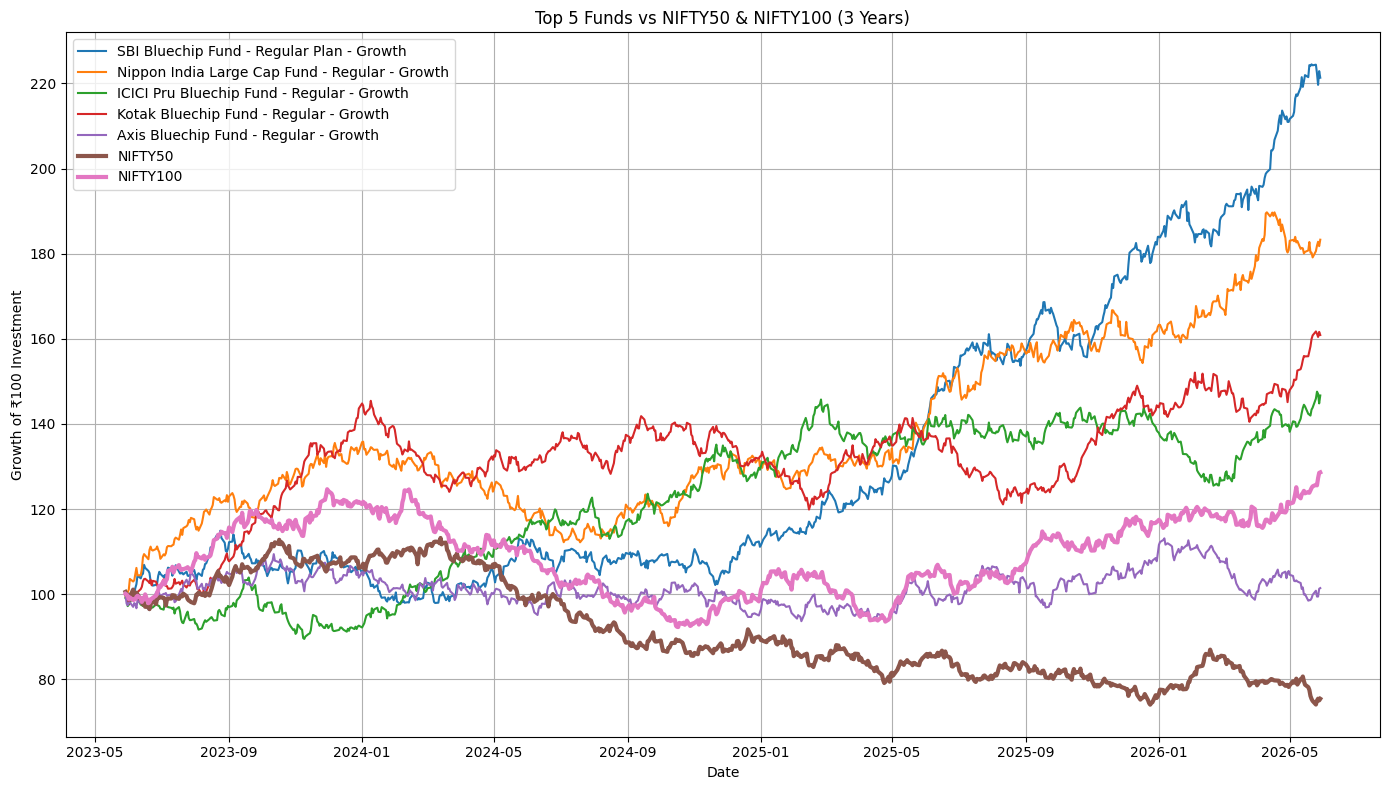


Tracking Error Results

   amfi_code  tracking_error_pct  \
3     120841               17.75   
4     119092               18.57   
2     120503               18.71   
1     118632               19.01   
0     119551               19.34   

                                      scheme_name  
3          Kotak Bluechip Fund - Regular - Growth  
4           Axis Bluechip Fund - Regular - Growth  
2      ICICI Pru Bluechip Fund - Regular - Growth  
1  Nippon India Large Cap Fund - Regular - Growth  
0       SBI Bluechip Fund - Regular Plan - Growth  


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Load Data
# ------------------------------------

scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

returns_df = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

# ------------------------------------
# Dates
# ------------------------------------

returns_df["date"] = pd.to_datetime(
    returns_df["date"]
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# ------------------------------------
# Top 5 Funds
# ------------------------------------

top5 = (
    scorecard
    .sort_values("fund_score",
                 ascending=False)
    .head(5)
)

top_funds = top5["amfi_code"].tolist()

# ------------------------------------
# Benchmark Returns
# ------------------------------------

bench = benchmark[
    benchmark["index_name"]
    .isin(["NIFTY50", "NIFTY100"])
].copy()

bench = bench.sort_values(
    ["index_name", "date"]
)

bench["benchmark_return"] = (
    bench.groupby("index_name")
    ["close_value"]
    .pct_change()
)

# ------------------------------------
# Last 3 Years
# ------------------------------------

latest_date = returns_df["date"].max()

start_date = (
    latest_date -
    pd.DateOffset(years=3)
)

returns_df = returns_df[
    returns_df["date"] >= start_date
]

bench = bench[
    bench["date"] >= start_date
]

# ------------------------------------
# Growth Curves
# ------------------------------------

plt.figure(figsize=(14,8))

tracking_error_results = []

# ------------------------------------
# Plot Top Funds
# ------------------------------------

for code in top_funds:

    fund = returns_df[
        returns_df["amfi_code"] == code
    ].copy()

    fund = fund.sort_values("date")

    fund["growth"] = (
        (1 + fund["daily_return"])
        .cumprod() * 100
    )

    name = (
        fund_master
        .loc[
            fund_master["amfi_code"] == code,
            "scheme_name"
        ]
        .iloc[0]
    )

    plt.plot(
        fund["date"],
        fund["growth"],
        label=name
    )

    # Tracking Error vs NIFTY100

    nifty100 = bench[
        bench["index_name"] ==
        "NIFTY100"
    ][["date",
       "benchmark_return"]]

    merged = pd.merge(
        fund[
            ["date",
             "daily_return"]
        ],
        nifty100,
        on="date",
        how="inner"
    )

    if len(merged) > 30:

        te = (
            np.std(
                merged["daily_return"]
                -
                merged["benchmark_return"]
            )
            * np.sqrt(252)
            * 100
        )

        tracking_error_results.append({
            "amfi_code": code,
            "tracking_error_pct":
                round(te,2)
        })

# ------------------------------------
# Plot Benchmarks
# ------------------------------------

for idx in ["NIFTY50",
            "NIFTY100"]:

    temp = bench[
        bench["index_name"] == idx
    ].copy()

    temp["growth"] = (
        (1 + temp["benchmark_return"])
        .cumprod() * 100
    )

    plt.plot(
        temp["date"],
        temp["growth"],
        linewidth=3,
        label=idx
    )

# ------------------------------------
# Format Chart
# ------------------------------------

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel(
    "Growth of ₹100 Investment"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_chart.png"
)

plt.show()

# ------------------------------------
# Tracking Error Output
# ------------------------------------

tracking_error_df = pd.DataFrame(
    tracking_error_results
)

tracking_error_df = (
    tracking_error_df.merge(
        fund_master[
            ["amfi_code",
             "scheme_name"]
        ],
        on="amfi_code",
        how="left"
    )
)

tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print(
    "\nTracking Error Results\n"
)

print(
    tracking_error_df.sort_values(
        "tracking_error_pct"
    )
)